# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Data Load

In [2]:
df = pd.read_csv('retail_sales_dataset.csv')
df

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,T0119996,2025-05-17,C002626,Other,25-34,VIP,P1064,Lamp,Home,Brand 1,1,181.59,30,127.11,Cash,Mobile App,South
119996,T0119997,2025-11-16,C007741,Male,55+,Loyal,P1015,Bluetooth Speaker,Electronics,Brand 3,4,95.00,0,380.00,Cash,In-Store,Central
119997,T0119998,2025-07-18,C000588,Female,55+,Loyal,P1083,Dumbbells,Sports,Brand 2,5,168.79,5,801.75,PayPal,Mobile App,South
119998,T0119999,2025-07-27,C009032,Other,35-44,VIP,P1008,Laptop,Electronics,Brand 2,3,433.76,0,1301.28,Debit Card,Mobile App,South


## Exploratory Data Analysis

In [3]:
df.shape

(120000, 17)

In [4]:
df.describe()

,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


In [5]:
df.nunique()

transaction_id        120000
transaction_date         730
customer_id            24784
customer_gender            3
customer_age_group         5
customer_segment           4
product_id               120
product_name              40
category                   8
brand                      3
quantity                   5
unit_price               120
discount_pct               7
sales_amount            3682
payment_method             5
sales_channel              3
region                     5
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       120000 non-nul

In [7]:
df.isna().sum()

transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['transaction_date']

0        2024-04-24
1        2025-07-12
2        2025-06-01
3        2025-08-26
4        2024-12-10
            ...    
119995   2025-05-17
119996   2025-11-16
119997   2025-07-18
119998   2025-07-27
119999   2025-01-27
Name: transaction_date, Length: 120000, dtype: datetime64[ns]

In [10]:
print(df['transaction_date'].dtype)

datetime64[ns]


In [11]:
df.fillna(0, inplace=True)
df

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,T0119996,2025-05-17,C002626,Other,25-34,VIP,P1064,Lamp,Home,Brand 1,1,181.59,30,127.11,Cash,Mobile App,South
119996,T0119997,2025-11-16,C007741,Male,55+,Loyal,P1015,Bluetooth Speaker,Electronics,Brand 3,4,95.00,0,380.00,Cash,In-Store,Central
119997,T0119998,2025-07-18,C000588,Female,55+,Loyal,P1083,Dumbbells,Sports,Brand 2,5,168.79,5,801.75,PayPal,Mobile App,South
119998,T0119999,2025-07-27,C009032,Other,35-44,VIP,P1008,Laptop,Electronics,Brand 2,3,433.76,0,1301.28,Debit Card,Mobile App,South


In [12]:
num_cols = ['quantity', 'unit_price', 'discount_pct', 'sales_amount']

cat_cols = ['customer_gender', 'customer_segment', 'product_name', 'category', 'brand', 'payment_method', 'sales_channel', 'region']

print(len(num_cols))
print(len(cat_cols))

4
8


## Visualization

### 1. Histogram Of Num_Cols

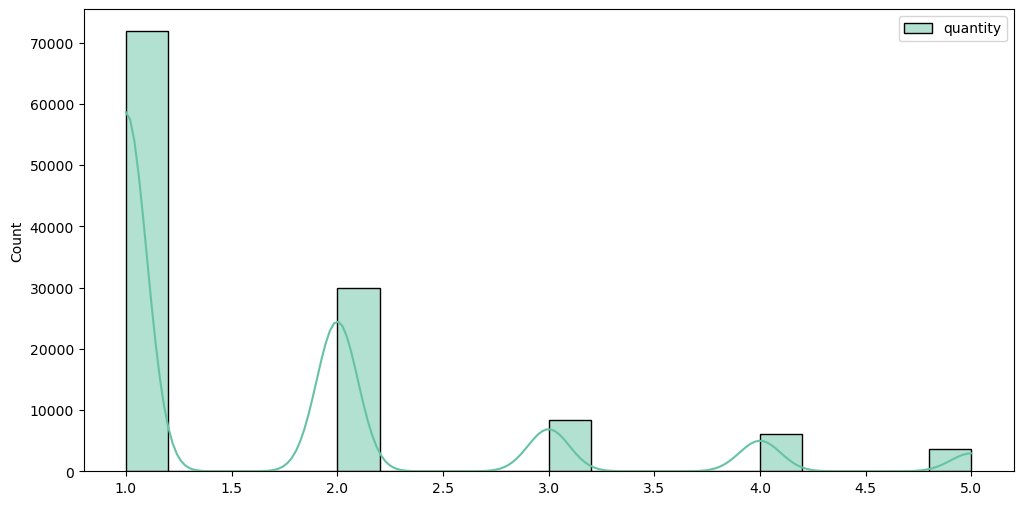

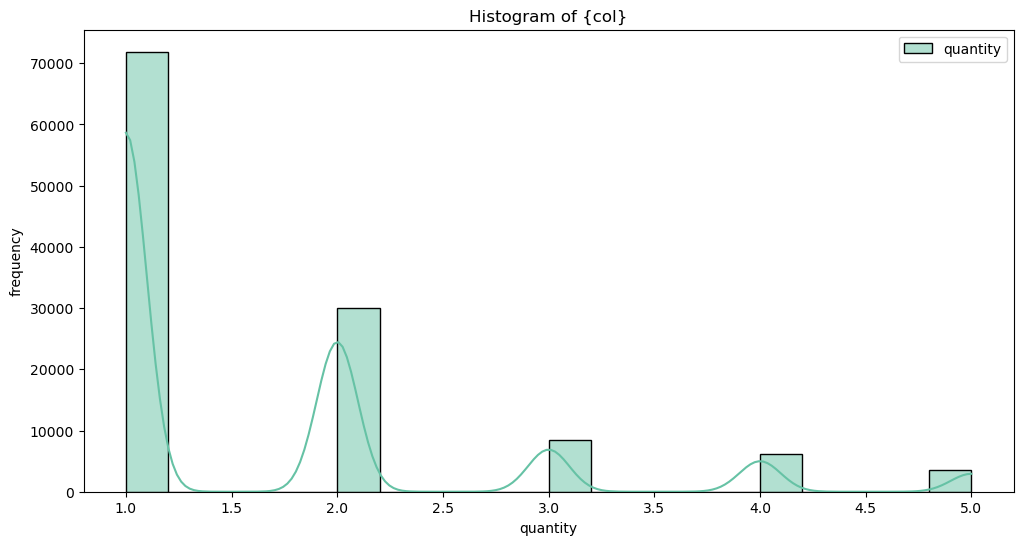

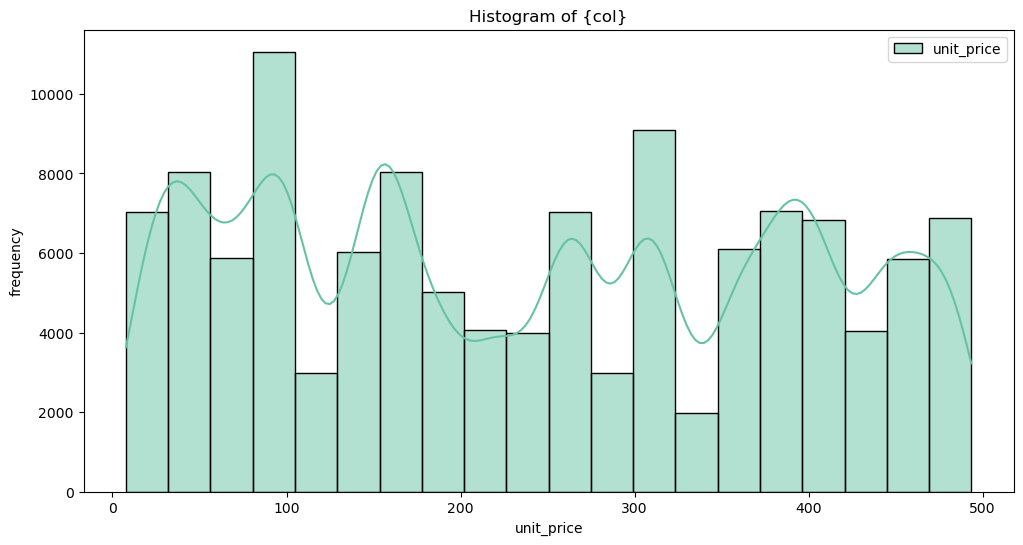

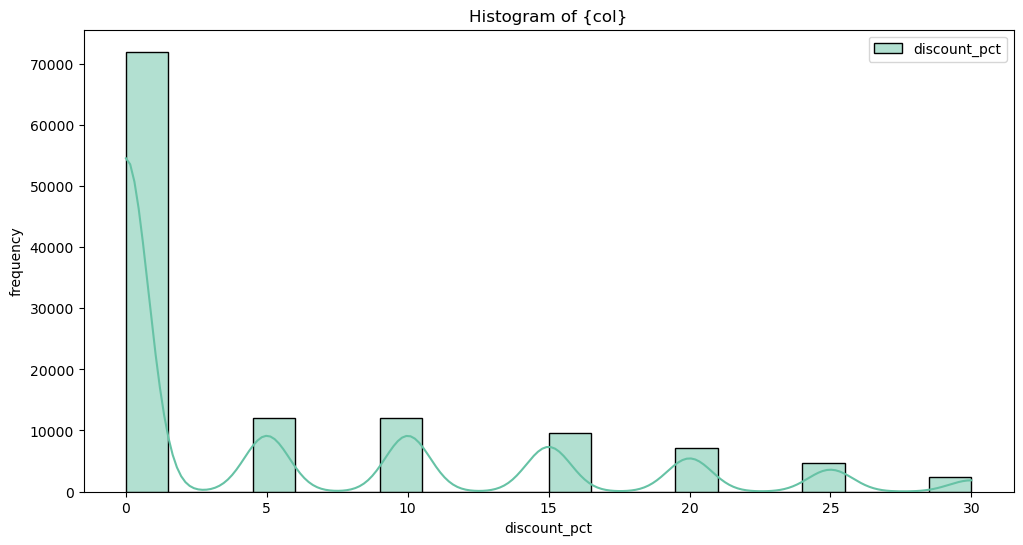

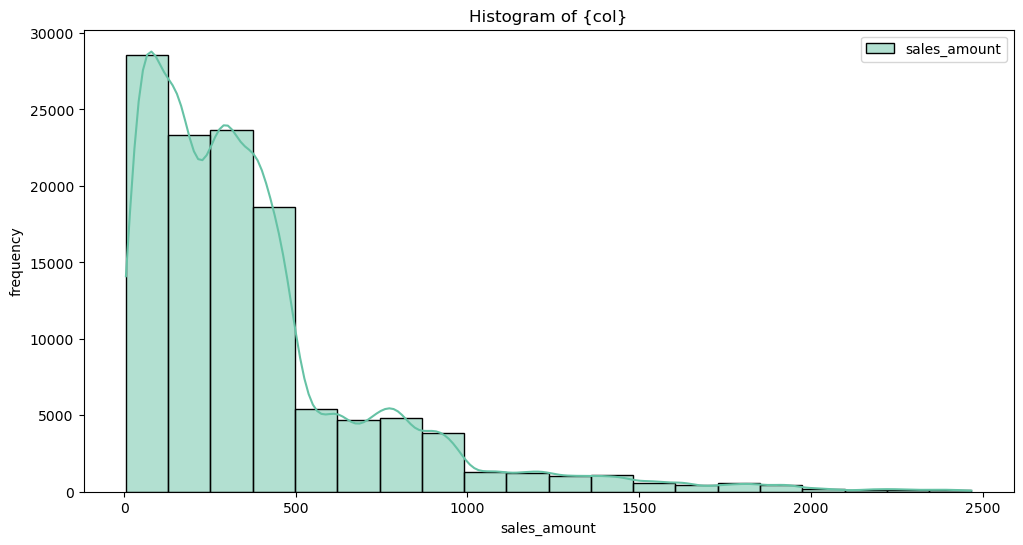

In [14]:
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[[col]], kde=True, palette='Set2', bins=20)
    plt.title('Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.tight_layout
    plt.show()

### 2. Countplot Of Cat_Cols

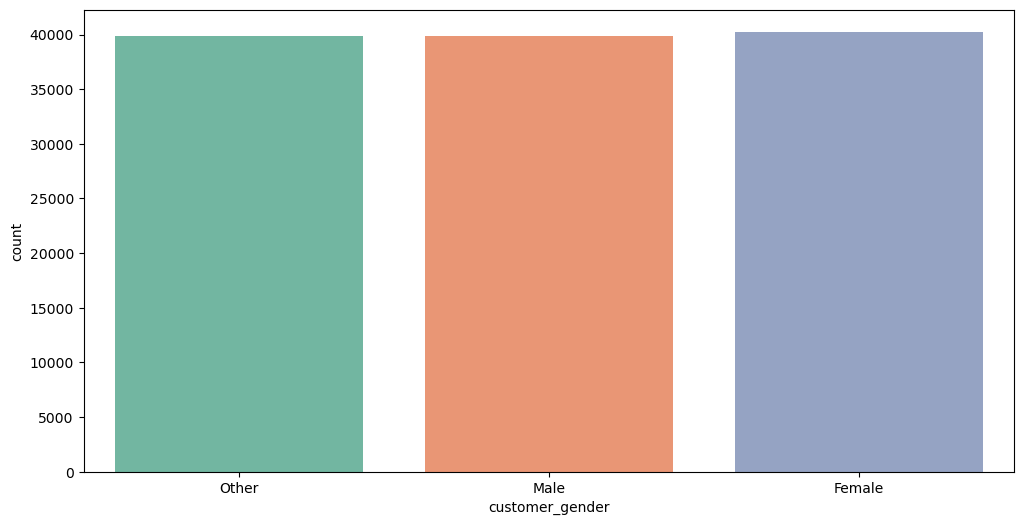

<Figure size 1200x600 with 0 Axes>

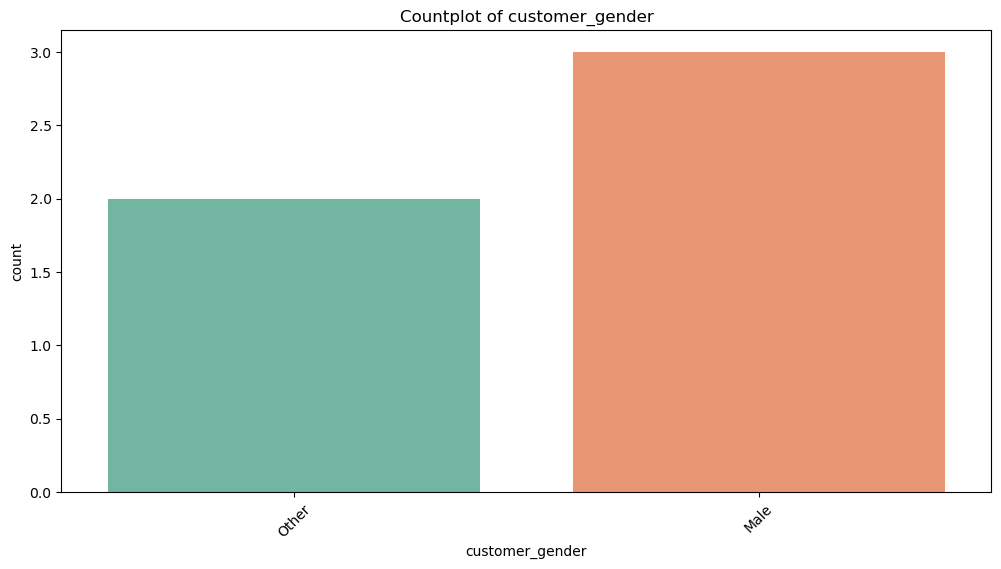

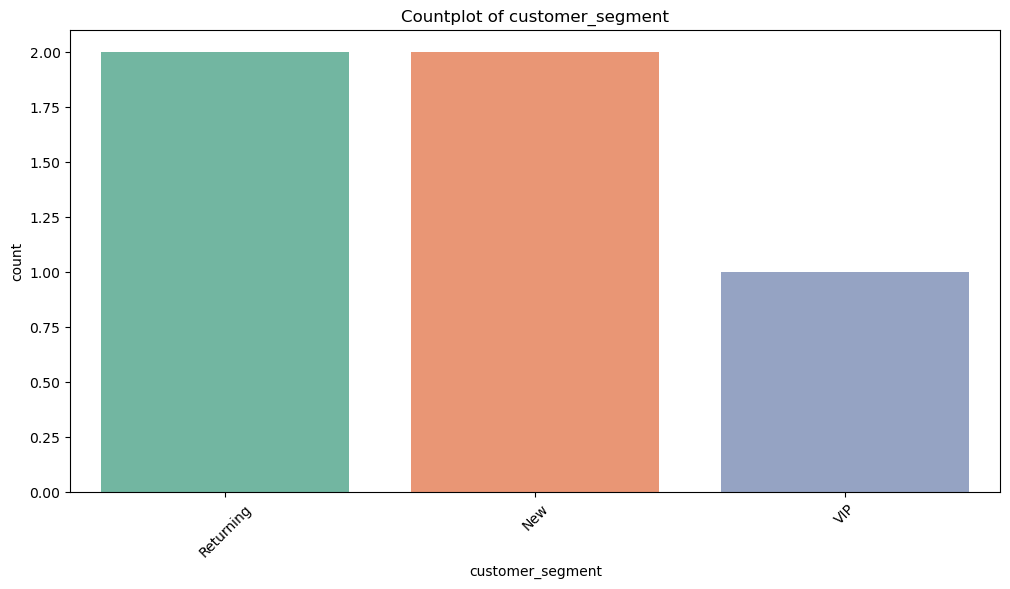

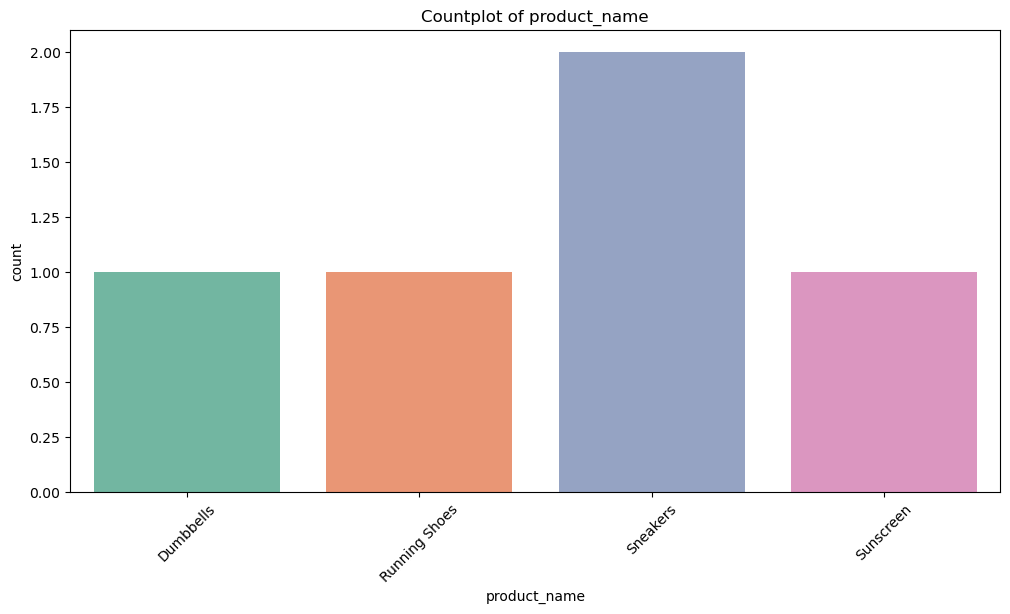

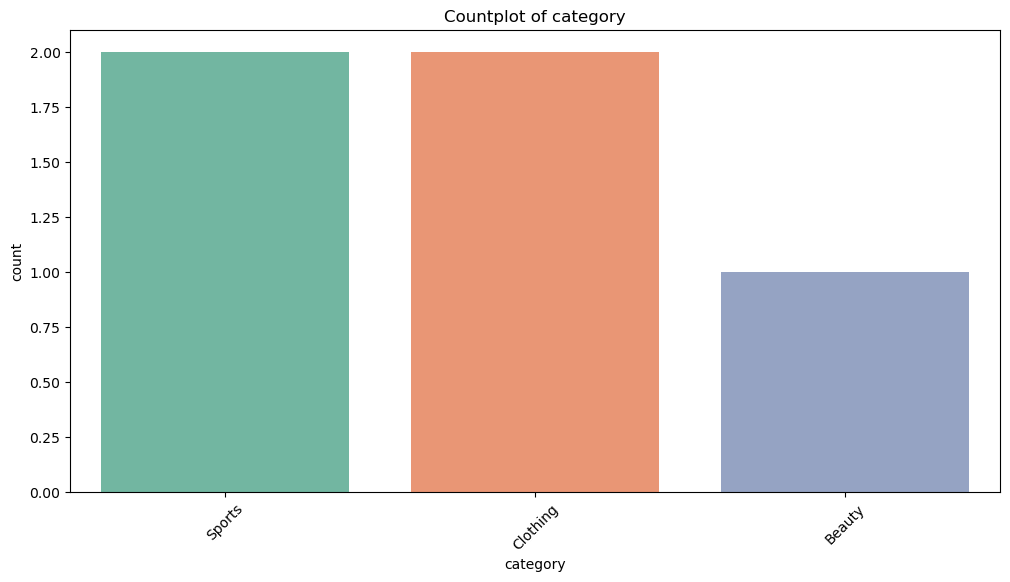

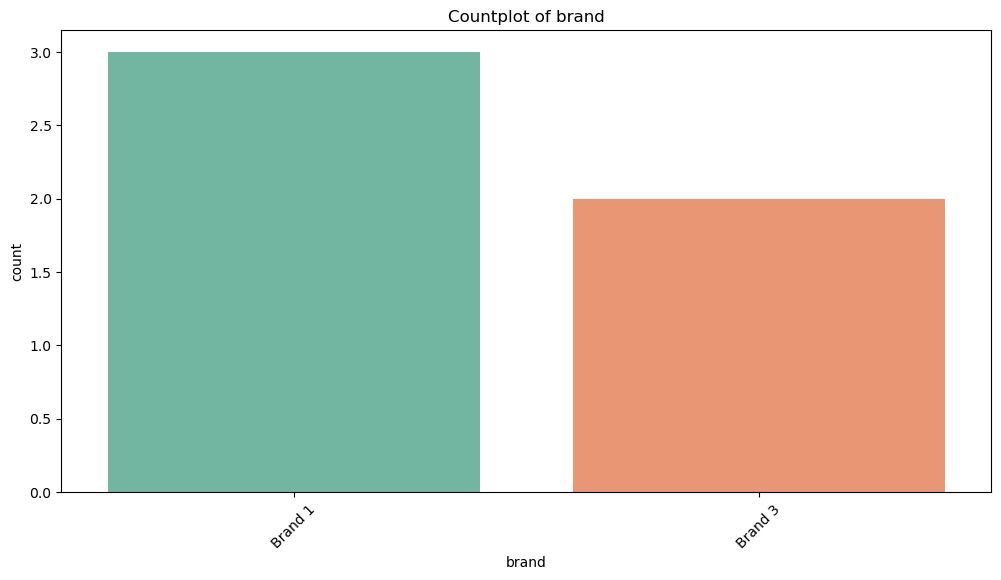

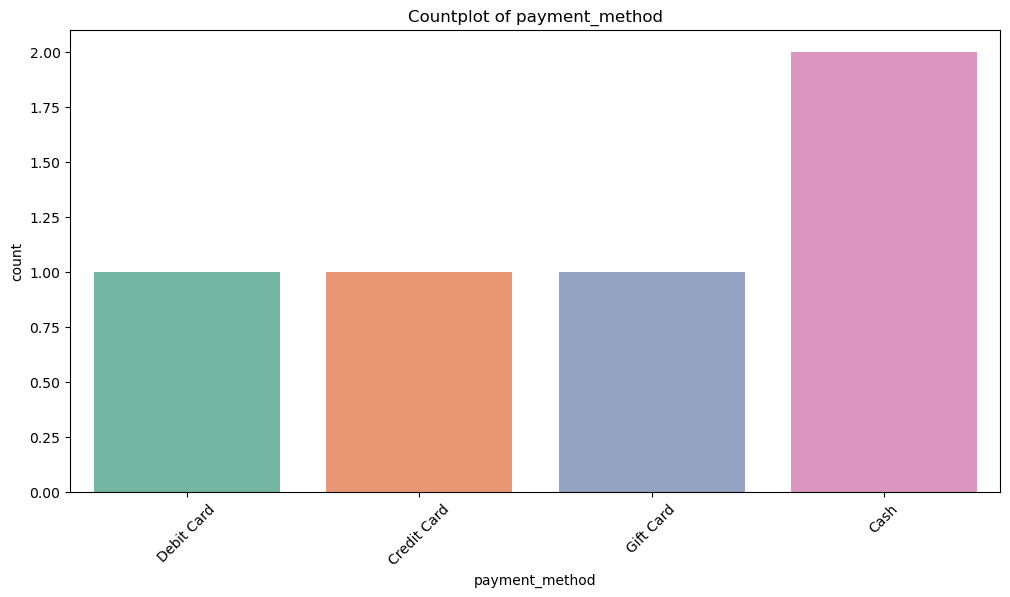

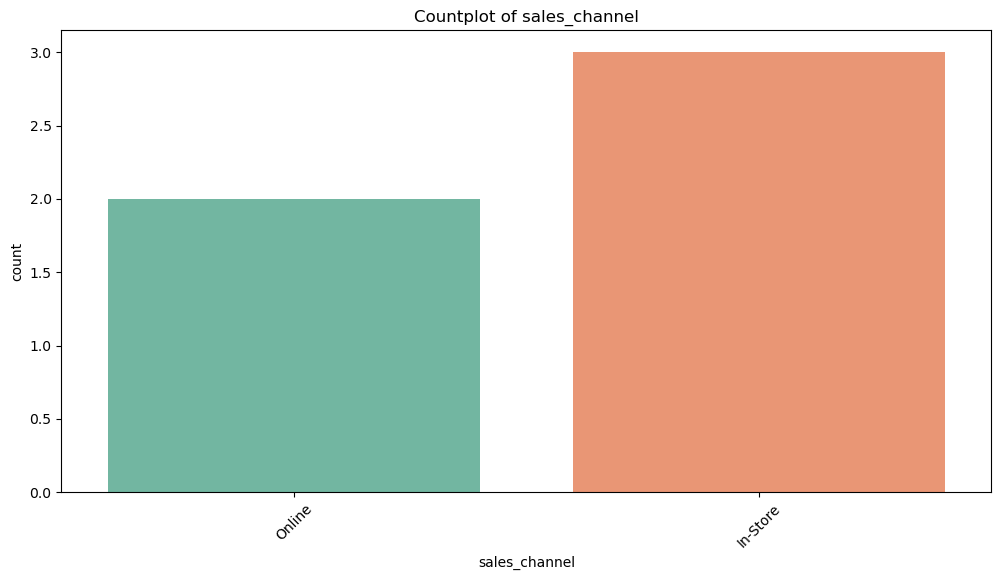

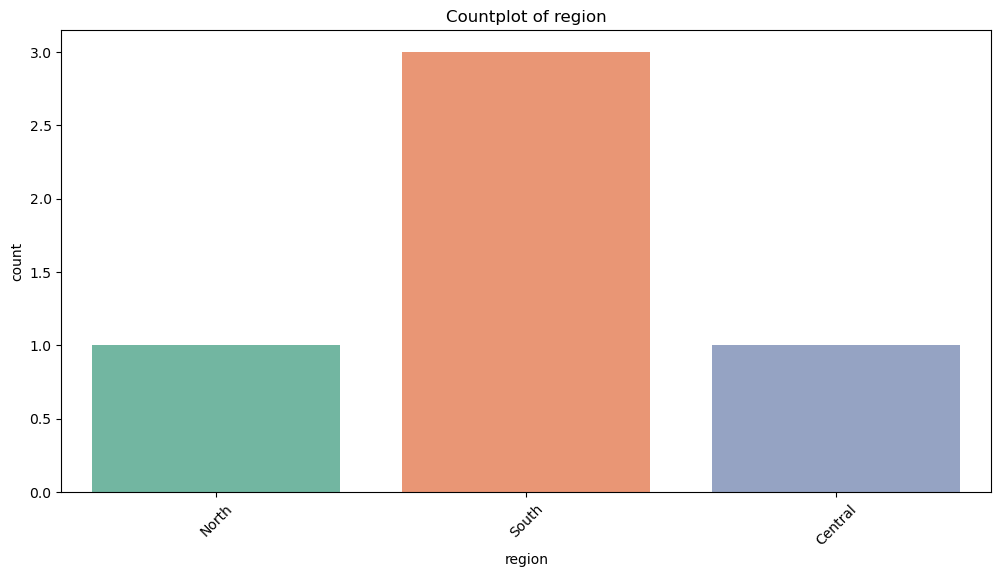

In [18]:
for col in cat_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df.head(), x=col, palette='Set2')
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.xticks(rotation=45)
    plt.tight_layout
    plt.show()

### 3. Unit Price vs Sales Amount By Sales Channel

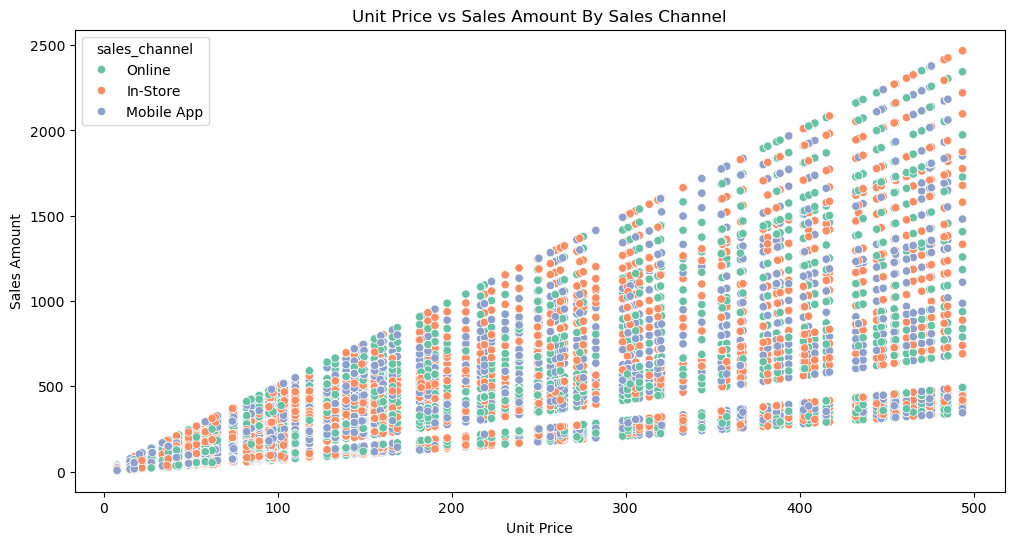

In [15]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['unit_price'], y=df['sales_amount'], hue=df['sales_channel'], palette='Set2')
plt.title('Unit Price vs Sales Amount By Sales Channel')
plt.xlabel('Unit Price')
plt.ylabel('Sales Amount')
plt.show()

### 4. Sales Amount By Transaction Date

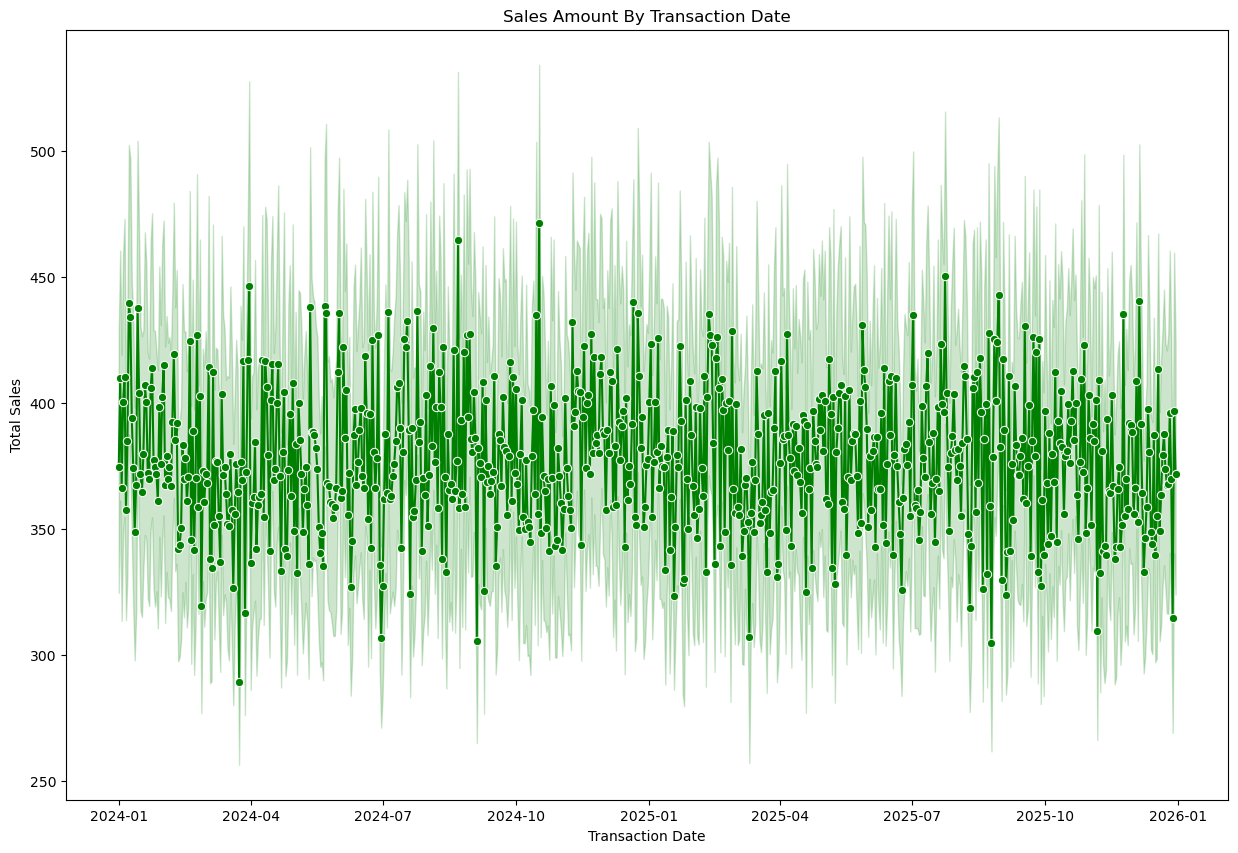

In [16]:
plt.figure(figsize=(15, 10))
sns.lineplot(x=df['transaction_date'], y=df['sales_amount'], marker='o', color='green')
plt.title('Sales Amount By Transaction Date')
plt.xlabel('Transaction Date')
plt.ylabel('Total Sales')
plt.show()

### 5. Sales Amount By Category

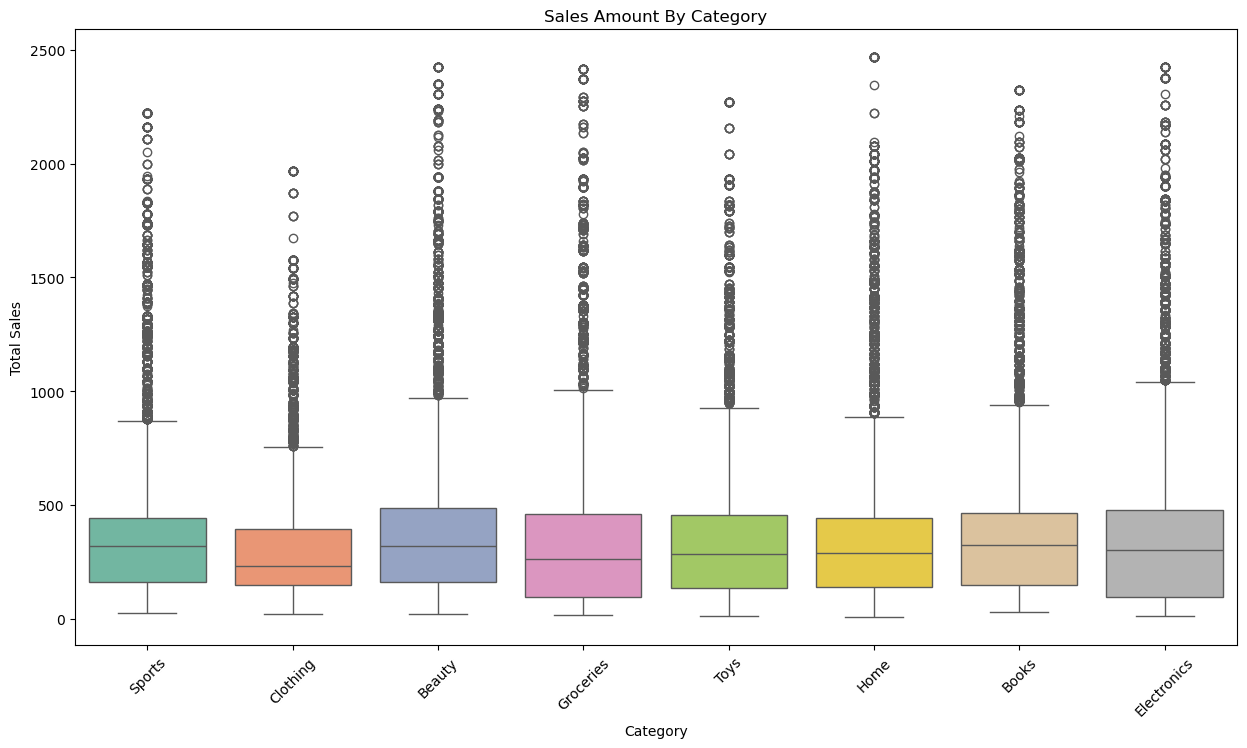

In [17]:
plt.figure(figsize=(15, 8))
sns.boxplot(x=df['category'], y=df['sales_amount'], data=df, palette='Set2')
plt.title('Sales Amount By Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

### 6. Total Sales vs Unit Price

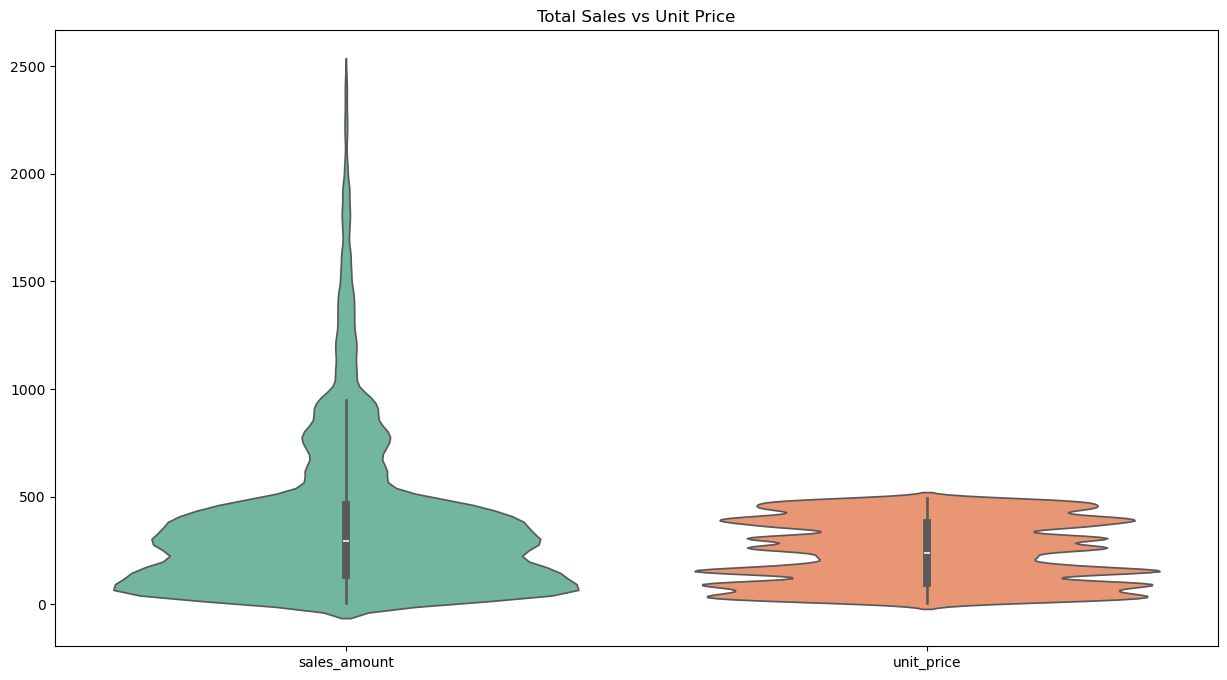

In [20]:
plt.figure(figsize=(15, 8))
sns.violinplot(data=df[['sales_amount', 'unit_price']], palette='Set2')
plt.title('Total Sales vs Unit Price')
plt.show()

### 7. Correlation Map

In [21]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df

,quantity,unit_price,discount_pct,sales_amount
0,2,313.53,20,501.65
1,1,366.16,0,366.16
2,1,27.99,0,27.99
3,2,102.01,15,173.42
4,1,259.55,0,259.55
...,...,...,...,...
119995,1,181.59,30,127.11
119996,4,95.00,0,380.00
119997,5,168.79,5,801.75
119998,3,433.76,0,1301.28


In [23]:
correlation = numeric_df.corr()

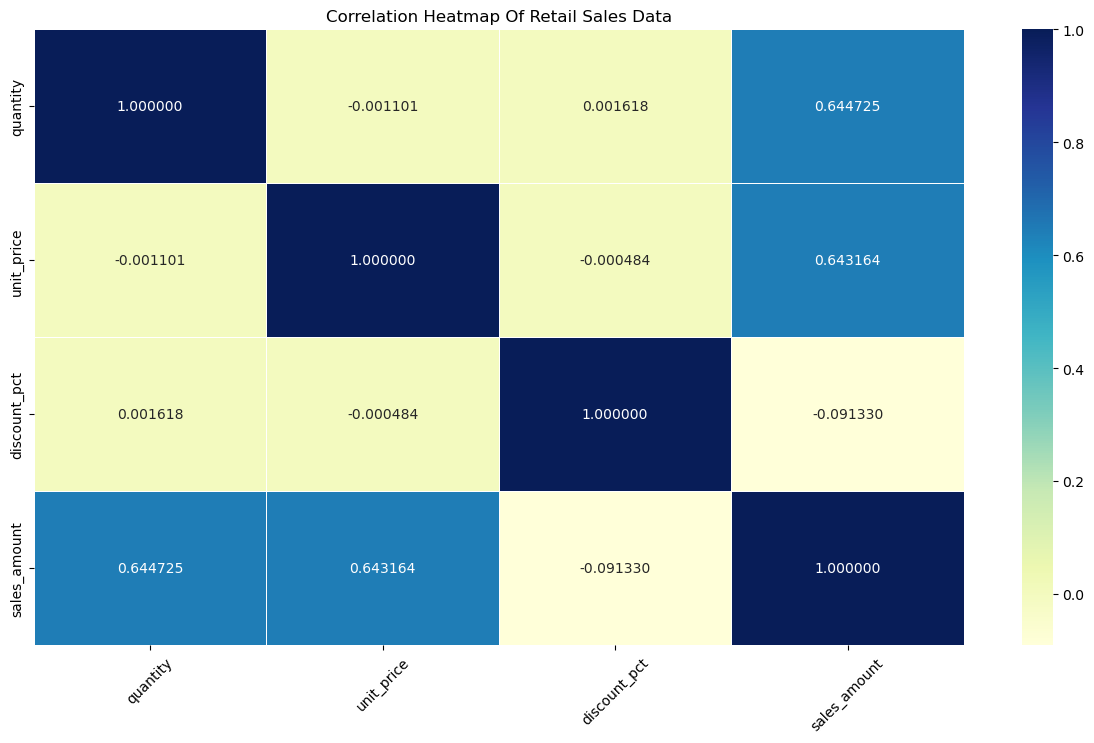

In [26]:
plt.figure(figsize=(15, 8))
sns.heatmap(correlation, annot=True, cmap='YlGnBu', fmt='2f', linewidth=0.5)
plt.title('Correlation Heatmap Of Retail Sales Data')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Predictive Modeling

In [28]:
df['customer_gender'].unique()

array(['Other', 'Male', 'Female'], dtype=object)

In [29]:
df['customer_segment'].unique()

array(['Returning', 'New', 'VIP', 'Loyal'], dtype=object)

In [30]:
df['category'].unique()

array(['Sports', 'Clothing', 'Beauty', 'Groceries', 'Toys', 'Home',
       'Books', 'Electronics'], dtype=object)

In [31]:
df['brand'].unique()

array(['Brand 1', 'Brand 3', 'Brand 2'], dtype=object)

In [32]:
df['payment_method'].unique()

array(['Debit Card', 'Credit Card', 'Gift Card', 'Cash', 'PayPal'],
      dtype=object)

In [33]:
df['sales_channel'].unique()

array(['Online', 'In-Store', 'Mobile App'], dtype=object)

In [34]:
df['region'].unique()

array(['North', 'South', 'Central', 'East', 'West'], dtype=object)

In [35]:
val = {'customer_gender': {'0': 'Other', 'Male': 1, 'Female': 2}, 
       'brand': {'Brand 1': 0, 'Brand 2': 1, 'Brand 3': 2},
       'sales_channel': {'In-Store': 0, 'Online': 1, 'Mobile App': 2}
       }
df.replace(val, inplace=True)
df

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,0,2,313.53,20,501.65,Debit Card,1,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,2,1,366.16,0,366.16,Credit Card,1,South
2,T0000003,2025-06-01,C019727,1,55+,Returning,P1030,Sneakers,Clothing,2,1,27.99,0,27.99,Gift Card,0,South
3,T0000004,2025-08-26,C009116,1,25-34,VIP,P1058,Sunscreen,Beauty,0,2,102.01,15,173.42,Cash,0,South
4,T0000005,2024-12-10,C003350,1,45-54,New,P1028,Sneakers,Clothing,0,1,259.55,0,259.55,Cash,0,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,T0119996,2025-05-17,C002626,Other,25-34,VIP,P1064,Lamp,Home,0,1,181.59,30,127.11,Cash,2,South
119996,T0119997,2025-11-16,C007741,1,55+,Loyal,P1015,Bluetooth Speaker,Electronics,2,4,95.00,0,380.00,Cash,0,Central
119997,T0119998,2025-07-18,C000588,2,55+,Loyal,P1083,Dumbbells,Sports,1,5,168.79,5,801.75,PayPal,2,South
119998,T0119999,2025-07-27,C009032,Other,35-44,VIP,P1008,Laptop,Electronics,1,3,433.76,0,1301.28,Debit Card,2,South


In [36]:
val = {'customer_gender': {'Other': 0}}
df.replace(val, inplace=True)
df

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,0,35-44,Returning,P1082,Dumbbells,Sports,0,2,313.53,20,501.65,Debit Card,1,North
1,T0000002,2025-07-12,C002849,0,45-54,New,P1087,Running Shoes,Sports,2,1,366.16,0,366.16,Credit Card,1,South
2,T0000003,2025-06-01,C019727,1,55+,Returning,P1030,Sneakers,Clothing,2,1,27.99,0,27.99,Gift Card,0,South
3,T0000004,2025-08-26,C009116,1,25-34,VIP,P1058,Sunscreen,Beauty,0,2,102.01,15,173.42,Cash,0,South
4,T0000005,2024-12-10,C003350,1,45-54,New,P1028,Sneakers,Clothing,0,1,259.55,0,259.55,Cash,0,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,T0119996,2025-05-17,C002626,0,25-34,VIP,P1064,Lamp,Home,0,1,181.59,30,127.11,Cash,2,South
119996,T0119997,2025-11-16,C007741,1,55+,Loyal,P1015,Bluetooth Speaker,Electronics,2,4,95.00,0,380.00,Cash,0,Central
119997,T0119998,2025-07-18,C000588,2,55+,Loyal,P1083,Dumbbells,Sports,1,5,168.79,5,801.75,PayPal,2,South
119998,T0119999,2025-07-27,C009032,0,35-44,VIP,P1008,Laptop,Electronics,1,3,433.76,0,1301.28,Debit Card,2,South


In [37]:
df = df.drop(columns=['customer_id'], errors='ignore')
df = df.drop(columns=['product_id'], errors='ignore')
df

,transaction_id,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,0,35-44,Returning,Dumbbells,Sports,0,2,313.53,20,501.65,Debit Card,1,North
1,T0000002,2025-07-12,0,45-54,New,Running Shoes,Sports,2,1,366.16,0,366.16,Credit Card,1,South
2,T0000003,2025-06-01,1,55+,Returning,Sneakers,Clothing,2,1,27.99,0,27.99,Gift Card,0,South
3,T0000004,2025-08-26,1,25-34,VIP,Sunscreen,Beauty,0,2,102.01,15,173.42,Cash,0,South
4,T0000005,2024-12-10,1,45-54,New,Sneakers,Clothing,0,1,259.55,0,259.55,Cash,0,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,T0119996,2025-05-17,0,25-34,VIP,Lamp,Home,0,1,181.59,30,127.11,Cash,2,South
119996,T0119997,2025-11-16,1,55+,Loyal,Bluetooth Speaker,Electronics,2,4,95.00,0,380.00,Cash,0,Central
119997,T0119998,2025-07-18,2,55+,Loyal,Dumbbells,Sports,1,5,168.79,5,801.75,PayPal,2,South
119998,T0119999,2025-07-27,0,35-44,VIP,Laptop,Electronics,1,3,433.76,0,1301.28,Debit Card,2,South


### 1. Train Test Split

In [38]:
features = ['quantity', 'unit_price', 'discount_pct', 'sales_amount', 'brand', 'sales_channel']

target = 'customer_gender'

X = df[features]
y = df[target]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(96000, 6) (24000, 6)


### 2. Models

In [40]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decison Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
}

In [41]:
best_model = None
best_accuracy = 0
best_model_name = ''

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n {name} Accuracy: {accuracy}')


 Logistic Regression Accuracy: 0.33441666666666664

 Decison Tree Accuracy: 0.34008333333333335

 Random Forest Accuracy: 0.33820833333333333

 Gradient Boosting Accuracy: 0.3335

 K-Nearest Neighbors Accuracy: 0.33325


#### Best Model

In [42]:
if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_model = model
    best_model_name = name
    print(f'\n Best Model: {best_model_name} with Accuracy: {best_accuracy}')


 Best Model: K-Nearest Neighbors with Accuracy: 0.33325


### 3. Classification Report

In [43]:
y_pred_best = best_model.predict(X_test)
print(f'\n Classification Report: \n', classification_report(y_test, y_pred_best))


 Classification Report: 
               precision    recall  f1-score   support

           0       0.34      0.46      0.39      7981
           1       0.33      0.31      0.32      8008
           2       0.33      0.23      0.27      8011

    accuracy                           0.33     24000
   macro avg       0.33      0.33      0.33     24000
weighted avg       0.33      0.33      0.33     24000



### 4. Confusion Matrix

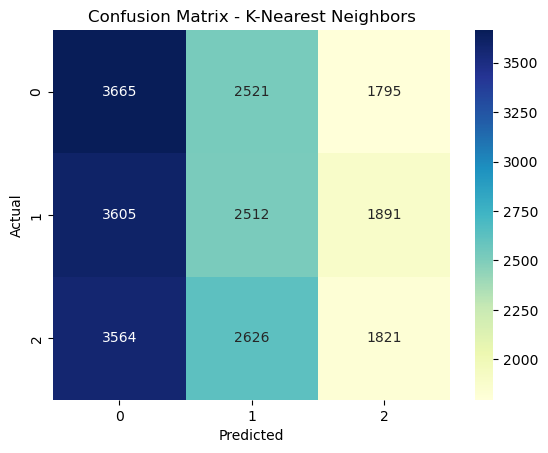

In [47]:
conf_matrix = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()